# Affinity Classification Diagnostics

This notebook computes a compact set of diagnostic metrics for ordinal affinity labels on `(abstract, question)` pairs.

Metrics included:
1. Confusion matrix against expert labels
2. Per-class recall
3. Quadratic Weighted Kappa
4. Mean signed error
5. Reliability curve

Optional: cluster bootstrap confidence intervals (disabled by default).

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, cohen_kappa_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [49]:
# Label definitions (edit only if your taxonomy changes).
LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
NUM_TO_LABEL = {0: "Low", 1: "Moderate", 2: "High"}


def normalize_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer)):
        return NUM_TO_LABEL.get(int(v), np.nan)
    s = str(v).strip()
    s_low = s.lower()
    if s_low in {"low", "moderate", "high"}:
        return s_low.capitalize()
    return np.nan


# Editable column names.
expert_col = "expert_label"
prediction_col = "final_label"
abstract_id_col = "abstract_id"

agreement_strength_col = None
panel_vote_cols = []

# Optional: per-model signed-bias diagnostics.
model_prediction_cols = []

# Optional cluster bootstrap (disabled by default).
RUN_BOOTSTRAP = False
N_BOOT = 500
BOOTSTRAP_SEED = 42

## Load Data

The loader tries likely project files first (including benchmark and calibration outputs), then you can override `input_path` manually if needed.

In [50]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"
calib_root = repo_root / "data" / "results" / "affinity_calibration"

benchmark_run_dir_names = ["20260422_212121_1", "20260422_212121_2", "20260422_212121_3"]
# calibration_run_dir_names = ["20260601_dummy_100_abstracts_v3"]
calibration_run_dir_names = ["20260618_Mark_batch1"]
benchmark_input_filename = "adjudicated_ra_model_rows.csv"
# calibration_input_filename = "calibration_dummy_abstract_question_affinities.csv"
calibration_input_filename = "calibration_abstract_question_affinities.csv"

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

benchmark_frames, selected_benchmark_dirs = collect_frames(
    bench_root, benchmark_run_dir_names, benchmark_input_filename, "benchmark"
)
calibration_frames, selected_calibration_dirs = collect_frames(
    calib_root, calibration_run_dir_names, calibration_input_filename, "calibration"
)

bench_df = pd.concat(benchmark_frames, ignore_index=True)
calib_df = pd.concat(calibration_frames, ignore_index=True)
df_raw = pd.merge(
    bench_df,
    calib_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_bench", "_calib"),
)

print("Benchmark run directories:", [p.name for p in selected_benchmark_dirs])
print("Calibration run directories:", [p.name for p in selected_calibration_dirs])
print("Calibration abstracts:", calib_df['Abstract_Index'].nunique())
print("Benchmark abstracts:", bench_df['Abstract_Index'].nunique())
print("Rows loaded:", len(df_raw))
print(f"Columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
display(df_raw.head(10))

Benchmark run directories: ['20260422_212121_1', '20260422_212121_2', '20260422_212121_3']
Calibration run directories: ['20260618_Mark_batch1']
Calibration abstracts: 21
Benchmark abstracts: 300
Rows loaded: 5998
Columns (23): ['Abstract_Index', 'Document Title_bench', 'RA2025_ID', 'RA_Question_bench', 'Cosine_x100', 'LLM_Affinity', 'LLM_Affinity_Reason', 'Model_Slug', 'Run_ID_bench', 'Abstract_Index_Norm', 'Affinity_Level', 'Final_Affinity', 'Final_Method', 'Final_Reason', 'Source_Type_bench', 'Document Title_calib', 'RA_Question_calib', 'Evaluator_Affinity', 'Evaluator_Affinity_Level', 'Evaluator_Affinity_Reason', 'Source_Evaluator', 'Run_ID_calib', 'Source_Type_calib']


,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Final_Reason,Source_Type_bench,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib
0,1,Scenario Reduction Network Based on Wasserstei...,41,what additional probabilistic planning methods...,48.1018,85,Directly addresses computational methods for p...,gemini-3.1-flash-lite,20260422_212121_1,1,...,NaN,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional probabilistic planning methods...,60,Moderate,NaN,Mark,20260618_Mark_batch1,calibration
1,1,Scenario Reduction Network Based on Wasserstei...,46,"what additional methods, tools, and metrics ar...",46.4117,60,Provides a computational tool for scenario red...,gemini-3.1-flash-lite,20260422_212121_1,1,...,Most models judged this as only indirectly rel...,benchmark,Scenario Reduction Network Based on Wasserstei...,"What additional methods, tools, and metrics ar...",10,Low,NaN,Mark,20260618_Mark_batch1,calibration
2,1,Scenario Reduction Network Based on Wasserstei...,21,what applications are required to assess adequ...,41.9768,50,Scenario reduction is a foundational step for ...,gemini-3.1-flash-lite,20260422_212121_1,1,...,The evidence consistently says the method is u...,benchmark,Scenario Reduction Network Based on Wasserstei...,What applications are required to assess adequ...,10,Low,NaN,Mark,20260618_Mark_batch1,calibration
3,1,Scenario Reduction Network Based on Wasserstei...,42,what additional planning models and methods ar...,41.1134,80,Directly improves planning models for handling...,gemini-3.1-flash-lite,20260422_212121_1,1,...,NaN,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1,calibration
4,1,Scenario Reduction Network Based on Wasserstei...,47,how do system operators adequately account for...,40.4033,55,Scenario reduction is essential for managing t...,gemini-3.1-flash-lite,20260422_212121_1,1,...,Several models noted scenario reduction can ma...,benchmark,Scenario Reduction Network Based on Wasserstei...,How do system operators adequately account for...,30,Low,NaN,Mark,20260618_Mark_batch1,calibration
5,1,Scenario Reduction Network Based on Wasserstei...,35,"what models and methods, including testing, ar...",34.7982,40,Indirectly supports reliability studies by ena...,gemini-3.1-flash-lite,20260422_212121_1,1,...,All models agree relevance is indirect at best...,benchmark,Scenario Reduction Network Based on Wasserstei...,"What models and methods, including testing, ar...",30,Low,NaN,Mark,20260618_Mark_batch1,calibration
6,1,Scenario Reduction Network Based on Wasserstei...,48,what additional planning models and methods ar...,34.3618,65,Efficient scenario reduction is critical for m...,gemini-3.1-flash-lite,20260422_212121_1,1,...,This is one of the stronger indirect matches b...,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1,calibration
7,1,Scenario Reduction Network Based on Wasserstei...,43,what changes can be incorporated into the tran...,33.7334,45,Supports the computational needs of complex in...,gemini-3.1-flash-lite,20260422_212121_1,1,...,The paper supports planning under uncertainty ...,benchmark,Scenario Reduction Network Based on Wasserstei...,What changes can be incorporated into the tran...,50,Moderate,NaN,Mark,20260618_Mark_batch1,calibration
8,1,Scenario Reduction Network Based on Wasserstei...,45,what additional load and resource forecasting ...,32.7660,40,Scenario reduction can be applied to forecasti...,gemini-3.1-flash-lite,20260422_212121_1,1,...,NaN,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional load and resource forecasting ...,10,Low

In [55]:
bench_df

,Abstract_Index,Document Title,RA2025_ID,RA_Question,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID,Abstract_Index_Norm,Affinity_Level,Final_Affinity,Final_Method,Final_Reason,Source_Type
0,1,Scenario Reduction Network Based on Wasserstei...,41,what additional probabilistic planning methods...,48.1018,85,Directly addresses computational methods for p...,gemini-3.1-flash-lite,20260422_212121_1,1,High,87.333333,ensemble_mean,NaN,benchmark
1,1,Scenario Reduction Network Based on Wasserstei...,46,"what additional methods, tools, and metrics ar...",46.4117,60,Provides a computational tool for scenario red...,gemini-3.1-flash-lite,20260422_212121_1,1,Moderate,47.000000,adjudicated_llm,Most models judged this as only indirectly rel...,benchmark
2,1,Scenario Reduction Network Based on Wasserstei...,21,what applications are required to assess adequ...,41.9768,50,Scenario reduction is a foundational step for ...,gemini-3.1-flash-lite,20260422_212121_1,1,Moderate,39.000000,adjudicated_llm,The evidence consistently says the method is u...,benchmark
3,1,Scenario Reduction Network Based on Wasserstei...,42,what additional planning models and methods ar...,41.1134,80,Directly improves planning models for handling...,gemini-3.1-flash-lite,20260422_212121_1,1,High,81.000000,ensemble_mean,NaN,benchmark
4,1,Scenario Reduction Network Based on Wasserstei...,47,how do system operators adequately account for...,40.4033,55,Scenario reduction is essential for managing t...,gemini-3.1-flash-lite,20260422_212121_1,1,Moderate,39.000000,adjudicated_llm,Several models noted scenario reduction can ma...,benchmark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86366,300,Data-Driven Emergency Frequency Control for Mu...,14,how can bulk-level services provided by der be...,8.0675,0,No valuation of bulk-level DER services is add...,mistral-large-3-675b-cloud,20260422_212121_3,300,Low,3.333333,ensemble_mean,NaN,benchmark
86367,300,Data-Driven Emergency Frequency Control for Mu...,24,how can the risk of high-impact low-probabilit...,7.7510,20,"Robustness analysis is mentioned, but high-imp...",mistral-large-3-675b-cloud,20260422_212121_3,300,Low,9.666667,ensemble_mean,NaN,benchmark
86368,300,Data-Driven Emergency Frequency Control for Mu...,37,what studies and metrics are required to ident...,7.0616,0,No studies or metrics for long-term resource s...,mistral-large-3-675b-cloud,20260422_212121_3,300,Low,3.333333,ensemble_mean,NaN,benchmark
86369,300,Data-Driven Emergency Frequency Control for Mu...,27,how can risk-based methods (e.g. probabilistic...,6.3851,30,Data-driven methods could aid risk-based decis...,mistral-large-3-675b-cloud,20260422_212121_3,300,Low,19.166667,ensemble_mean,NaN,benchmark


In [38]:
def infer_column(columns, preferred, fallback):
    if preferred in columns:
        return preferred
    lower_map = {str(c).strip().lower(): c for c in columns}
    for name in fallback:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

expert_col_inferred = infer_column(
    df_raw.columns,
    expert_col,
    [
        'expert_label', 'benchmark_label', 
        'expert_affinity', 'gold_label', 'gold_affinity', 'Evaluator_Affinity_Level'
    ],
)
prediction_col_inferred = infer_column(
    df_raw.columns,
    prediction_col,
    [
        'Affinity_Level'
    ],
)
abstract_id_col_inferred = infer_column(
    df_raw.columns,
    abstract_id_col,
    ['abstract_id', 'Abstract_Index', 'abstract_index', 'Source_Index'],
)

print('Column mapping in use:')
print(f'  expert_col      -> {expert_col_inferred}')
print(f'  prediction_col  -> {prediction_col_inferred}')
print(f'  abstract_id_col -> {abstract_id_col_inferred}')

if expert_col_inferred is None or prediction_col_inferred is None:
    raise ValueError(
        'Could not find expert/prediction label columns automatically. '
        'Please edit expert_col and prediction_col near the top of this notebook.'
    )

Column mapping in use:
  expert_col      -> Evaluator_Affinity_Level
  prediction_col  -> Affinity_Level
  abstract_id_col -> Abstract_Index


In [54]:
df_raw.Model_Slug.unique()

array(['gemini-3.1-flash-lite', 'gemma4-31b-cloud', 'gpt-5.4',
       'gpt-5.4-mini', 'ministral-3-14b-cloud',
       'mistral-large-3-675b-cloud'], dtype=object)

## Clean Labels

The cleaner normalizes variants such as `low`, `LOW`, `med`, `medium`, and `high`, then maps labels to ordinal values:

- Low = 0
- Medium = 1
- High = 2

In [40]:
# Assume labels are already canonical: 'Low', 'Moderate', 'High'.
# We only coerce simple numeric encodings (0/1/2) and case-insensitive canonical names.
eval_df = df_raw.copy()
rows_before = len(eval_df)

def _to_canonical_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer)):
        return NUM_TO_LABEL.get(int(v), np.nan)
    s = str(v).strip()
    s_low = s.lower()
    if s_low in {'low', 'moderate', 'high'}:
        return s_low.capitalize()
    return np.nan


eval_df['expert_label_clean'] = eval_df[expert_col_inferred].apply(_to_canonical_label)
eval_df['pred_label_clean'] = eval_df[prediction_col_inferred].apply(_to_canonical_label)

eval_df = eval_df.dropna(subset=['expert_label_clean', 'pred_label_clean']).copy()
eval_df['expert_num'] = eval_df['expert_label_clean'].map(LABEL_TO_NUM).astype(int)
eval_df['pred_num'] = eval_df['pred_label_clean'].map(LABEL_TO_NUM).astype(int)

rows_after = len(eval_df)
rows_removed = rows_before - rows_after

print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning:  {rows_after:,}')
print(f'Rows removed:         {rows_removed:,}')

print(f'Evaluated (abstract, question) pairs after cleaning: {rows_after:,}')
if abstract_id_col_inferred is not None and abstract_id_col_inferred in eval_df.columns:
    print(f'Unique abstracts: {eval_df[abstract_id_col_inferred].nunique():,}')
else:
    print('Unique abstracts: not available (abstract_id_col not found).')

Rows before cleaning: 5,998
Rows after cleaning:  5,998
Rows removed:         0
Evaluated (abstract, question) pairs after cleaning: 5,998
Unique abstracts: 21


## Metric 1: Confusion Matrix Against Expert Labels

In [41]:
df_raw.Abstract_Index.unique().size

21

,Predicted Low,Predicted Medium,Predicted High
Expert Low,4679,705,234
Expert Medium,89,121,165
Expert High,0,1,4


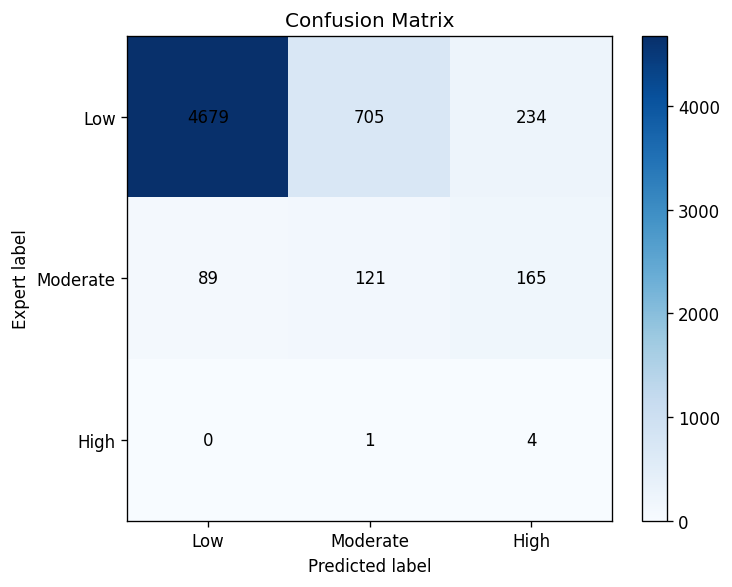

In [42]:
y_true = eval_df['expert_num'].to_numpy()
y_pred = eval_df['pred_num'].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=['Expert Low', 'Expert Medium', 'Expert High'],
    columns=['Predicted Low', 'Predicted Medium', 'Predicted High'],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Low', 'Moderate', 'High'])
ax.set_yticklabels(['Low', 'Moderate', 'High'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('Expert label')
ax.set_title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Metric 2: Per-Class Recall

In [43]:
recalls = recall_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
recall_df = pd.DataFrame({
    'Class': LABEL_ORDER,
    'Recall': recalls,
    'Interpretation': [
        'Ability to identify low-affinity pairs',
        'Ability to identify medium-affinity pairs',
        'Ability to identify high-affinity pairs',
    ],
})
display(recall_df)

,Class,Recall,Interpretation
0,Low,0.832859,Ability to identify low-affinity pairs
1,Moderate,0.322667,Ability to identify medium-affinity pairs
2,High,0.800000,Ability to identify high-affinity pairs


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [44]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))

print(f'Quadratic Weighted Kappa = {qwk:.4f}')
print(f'Mean signed error        = {mean_signed_error:.4f}')

if model_prediction_cols:
    model_bias_rows = []
    for col in model_prediction_cols:
        if col not in eval_df.columns:
            continue

        pred_clean = eval_df[col].map(normalize_label)
        temp = eval_df[['expert_num']].copy()
        temp['pred_clean'] = pred_clean
        temp = temp.dropna(subset=['pred_clean'])
        if temp.empty:
            continue

        temp['pred_num_model'] = temp['pred_clean'].map(LABEL_TO_NUM).astype(int)
        mse_model = float(np.mean(temp['pred_num_model'] - temp['expert_num']))
        model_bias_rows.append({'model_prediction_col': col, 'mean_signed_error': mse_model, 'n_pairs': len(temp)})

    if model_bias_rows:
        display(pd.DataFrame(model_bias_rows).sort_values('mean_signed_error', ascending=False))
    else:
        print('No valid model-level bias rows were computed.')

Quadratic Weighted Kappa = 0.2775
Mean signed error        = 0.2081


## Metric 5: Reliability Curve

If `agreement_strength_col` is present, it is used directly.
Otherwise, if `panel_vote_cols` is provided, agreement strength is computed as the fraction of panel votes matching the final predicted label.

In [45]:
reliability_df = None

def compute_agreement_strength(row, pred_col, vote_cols):
    final_label = row[pred_col]
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(normalize_label)
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0:
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))

if agreement_strength_col is not None and agreement_strength_col in eval_df.columns:
    work = eval_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in eval_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = eval_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=('pred_label_clean', panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        bins = [0.0, 0.5, 0.67, 0.83, 1.0]
        rel['agreement_bin'] = pd.cut(rel['agreement_strength'], bins=bins, include_lowest=True)

        reliability_df = (
            rel.groupby('agreement_bin', observed=False)
            .agg(n_cases=('is_correct', 'size'), accuracy=('is_correct', 'mean'))
            .reset_index()
        )
        reliability_df = reliability_df[reliability_df['n_cases'] > 0].copy()
        reliability_df['bin_midpoint'] = reliability_df['agreement_bin'].apply(lambda x: x.mid)

        display(reliability_df[['agreement_bin', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(reliability_df['bin_midpoint'], reliability_df['accuracy'], marker='o')
        ax.set_xlabel('Agreement strength (bin midpoint)')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title('Reliability Curve')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.


## Optional: Cluster Bootstrap Confidence Intervals

Bootstrap resamples complete abstracts (clusters), not individual rows.

Set `RUN_BOOTSTRAP = True` near the top to run this section.

In [46]:
bootstrap_summary = None

if RUN_BOOTSTRAP:
    if abstract_id_col_inferred is None or abstract_id_col_inferred not in eval_df.columns:
        print('Bootstrap skipped: abstract_id_col is missing.')
    else:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
        abstract_ids = pd.Series(eval_df[abstract_id_col_inferred].dropna().unique())

        if len(abstract_ids) == 0:
            print('Bootstrap skipped: no abstract IDs available.')
        else:
            qwk_samples = []
            mse_samples = []
            recall_samples = []

            for _ in range(N_BOOT):
                sampled_ids = rng.choice(abstract_ids.to_numpy(), size=len(abstract_ids), replace=True)
                sampled_parts = [eval_df[eval_df[abstract_id_col_inferred] == aid] for aid in sampled_ids]
                boot_df = pd.concat(sampled_parts, ignore_index=True)

                y_t = boot_df['expert_num'].to_numpy()
                y_p = boot_df['pred_num'].to_numpy()

                qwk_samples.append(cohen_kappa_score(y_t, y_p, weights='quadratic'))
                mse_samples.append(float(np.mean(y_p - y_t)))
                recall_samples.append(recall_score(y_t, y_p, labels=[0, 1, 2], average=None, zero_division=0))

            recall_arr = np.vstack(recall_samples)

            def ci(values, alpha=0.05):
                lo = np.nanpercentile(values, 100 * (alpha / 2))
                hi = np.nanpercentile(values, 100 * (1 - alpha / 2))
                return float(lo), float(hi)

            qwk_ci = ci(np.array(qwk_samples))
            mse_ci = ci(np.array(mse_samples))
            low_ci = ci(recall_arr[:, 0])
            med_ci = ci(recall_arr[:, 1])
            high_ci = ci(recall_arr[:, 2])

            bootstrap_summary = pd.DataFrame([
                {'Metric': 'Quadratic Weighted Kappa', 'CI_2.5%': qwk_ci[0], 'CI_97.5%': qwk_ci[1]},
                {'Metric': 'Recall Low', 'CI_2.5%': low_ci[0], 'CI_97.5%': low_ci[1]},
                {'Metric': 'Recall Medium', 'CI_2.5%': med_ci[0], 'CI_97.5%': med_ci[1]},
                {'Metric': 'Recall High', 'CI_2.5%': high_ci[0], 'CI_97.5%': high_ci[1]},
                {'Metric': 'Mean Signed Error', 'CI_2.5%': mse_ci[0], 'CI_97.5%': mse_ci[1]},
            ])
            display(bootstrap_summary)
else:
    print('Bootstrap disabled (RUN_BOOTSTRAP = False).')

Bootstrap disabled (RUN_BOOTSTRAP = False).


## Final Summary Table

In [47]:
summary_rows = [
    {'Quantity': 'Evaluated pairs', 'Value': int(len(eval_df))},
    {
        'Quantity': 'Unique abstracts',
        'Value': int(eval_df[abstract_id_col_inferred].nunique())
        if abstract_id_col_inferred is not None and abstract_id_col_inferred in eval_df.columns
        else 'N/A',
    },
    {'Quantity': 'Quadratic Weighted Kappa', 'Value': float(qwk)},
    {'Quantity': 'Low recall', 'Value': float(recalls[0])},
    {'Quantity': 'Medium recall', 'Value': float(recalls[1])},
    {'Quantity': 'High recall', 'Value': float(recalls[2])},
    {'Quantity': 'Mean signed error', 'Value': float(mean_signed_error)},
]

if reliability_df is not None and len(reliability_df) > 0:
    summary_rows.extend([
        {'Quantity': 'Reliability curve available', 'Value': 'Yes'},
        {'Quantity': 'Lowest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].min())},
        {'Quantity': 'Highest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].max())},
    ])
else:
    summary_rows.append({'Quantity': 'Reliability curve available', 'Value': 'No'})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Quantity,Value
0,Evaluated pairs,5998
1,Unique abstracts,21
2,Quadratic Weighted Kappa,0.277539
3,Low recall,0.832859
4,Medium recall,0.322667
5,High recall,0.8
6,Mean signed error,0.208069
7,Reliability curve available,No


## Practical Decision Rules

- Good Quadratic Weighted Kappa and balanced recall across Low, Medium, and High: the three-class pipeline is likely acceptable.
- Poor Medium recall: the Medium category may be unstable; consider a binary first-stage classifier followed by adjudication of relevant cases.
- Good Low and High recall but weak Medium recall: the panel may be behaving as a binary relevant/not-relevant classifier.
- Positive mean signed error: the pipeline tends to overestimate affinity.
- Negative mean signed error: the pipeline tends to underestimate affinity.
- Mean signed error near zero: no average directional bias, but performance may still be poor.
- Increasing reliability curve: panel agreement or confidence is informative.
- Flat reliability curve: possible correlated or monoculture error.
- High-agreement cases with low accuracy: strong evidence of shared model bias relative to the expert.